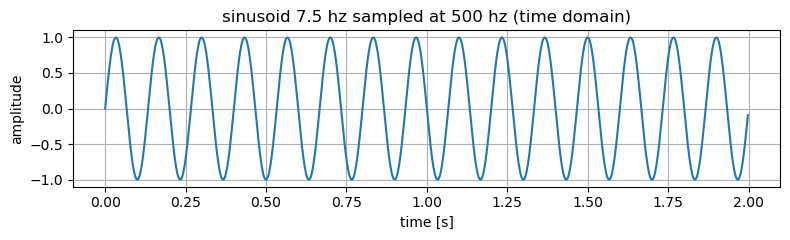

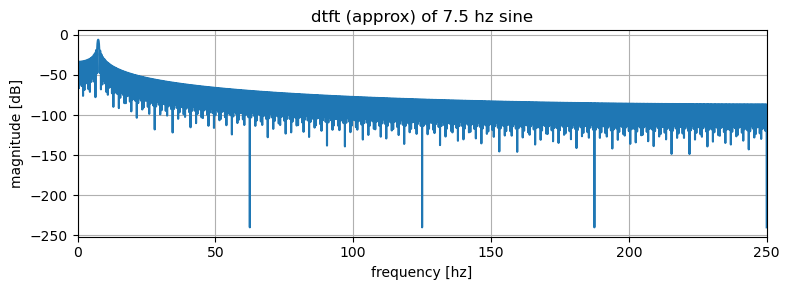

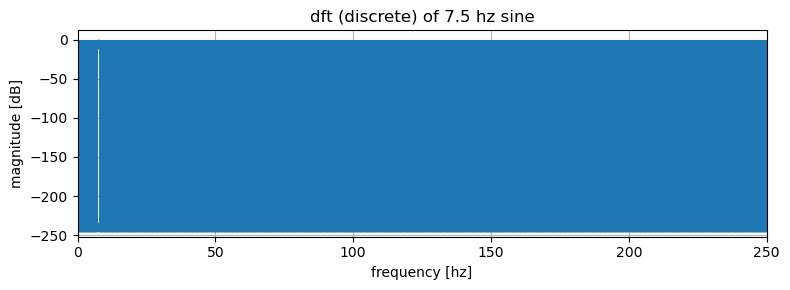

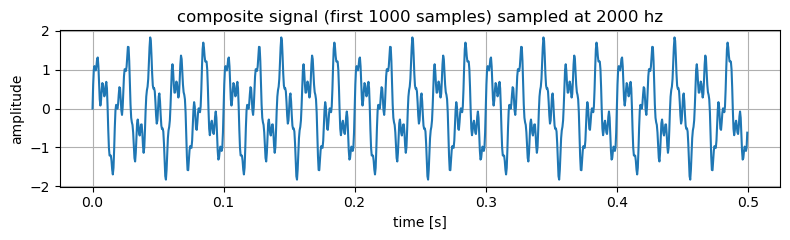

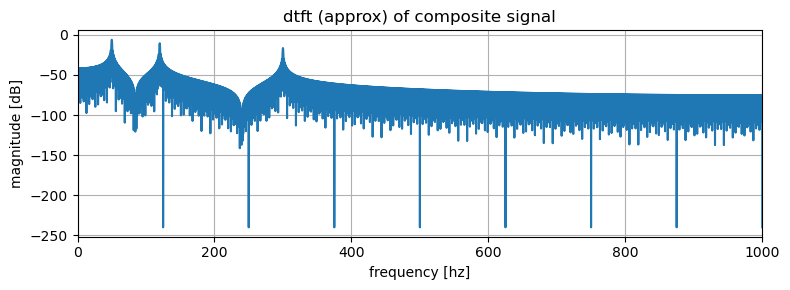

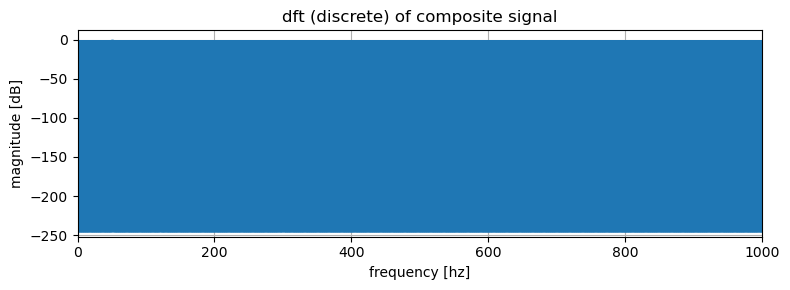

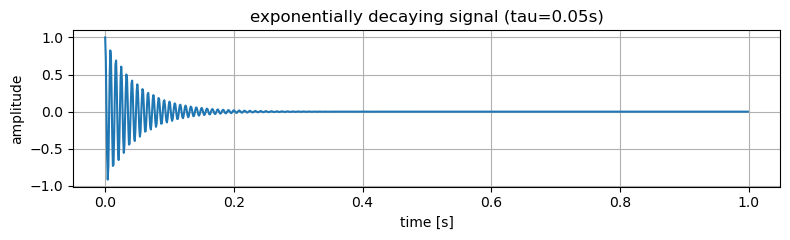

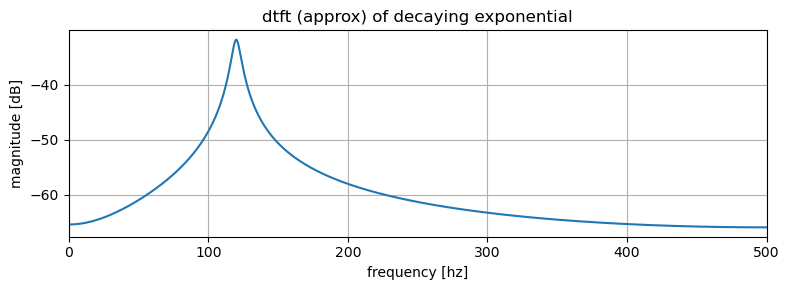

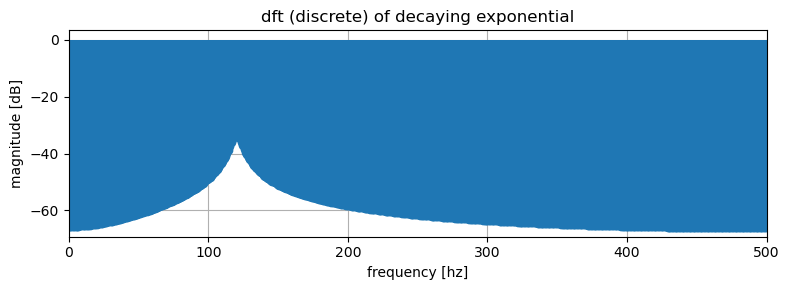

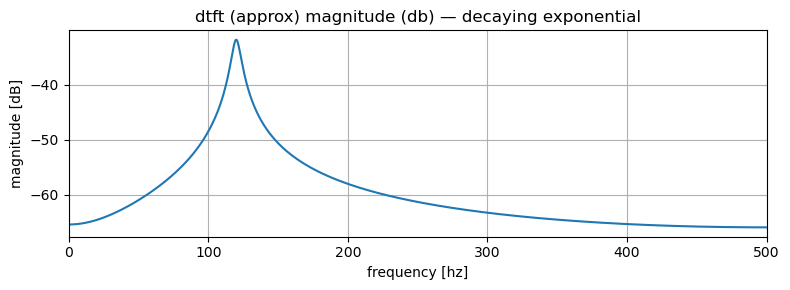

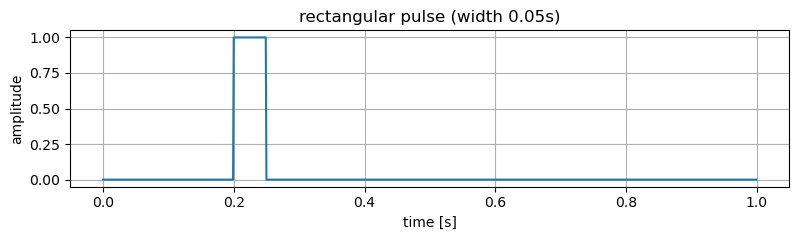

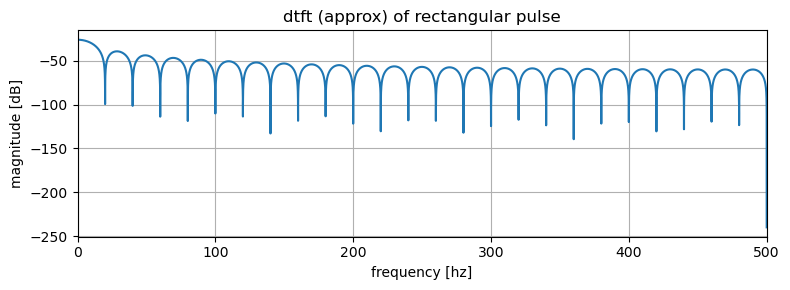

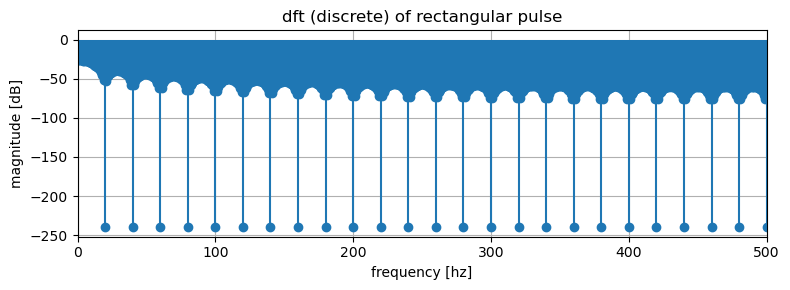


q1 - sinusoid (7.5 hz) metrics:
  total spectral energy: 8.192000e+00
  energy in main region: 8.070803e+00
  concentration ratio (main/total): 0.985205
  leakage ratio (1 - concentration): 0.014795
  bandwidth containing 90% energy: 7.75 hz
  spectral centroid: 7.45 hz

q2 - composite (50,120,300 hz) metrics:
  total spectral energy: 1.187840e+01
  energy in main region: 1.148033e+01
  concentration ratio (main/total): 0.966488
  leakage ratio (1 - concentration): 0.033512
  bandwidth containing 90% energy: 120.42 hz
  spectral centroid: 82.70 hz

q3 - decaying tone (~120 hz carrier) metrics:
  total spectral energy: 4.263883e-01
  energy in main region: 4.049403e-01
  concentration ratio (main/total): 0.949698
  leakage ratio (1 - concentration): 0.050302
  bandwidth containing 90% energy: 132.68 hz
  spectral centroid: 124.87 hz

q4 - rectangular pulse metrics:
  total spectral energy: 1.639650e+00
  energy in main region: 1.625302e+00
  concentration ratio (main/total): 0.991249
 

In [3]:
# fourier transform and frequency-spectrum analysis
# q1-q4: sinusoid, composite, exponential, rectangular pulse

import numpy as np
import matplotlib.pyplot as plt

# helper functions --
def compute_dtft(sig, fs, nfft=65536):
    """
    approximate dtft by computing a high-resolution rfft (zero-padded).
    returns (freqs, magnitude_linear).
    """
    S = np.fft.rfft(sig, n=nfft)
    freqs = np.fft.rfftfreq(nfft, d=1.0/fs)
    mag = np.abs(S) / len(sig)   # normalize by original length for amplitude reference
    return freqs, mag

def compute_dft(sig, fs):
    """
    compute the dft (rfft version for real signal).
    returns (freqs, magnitude_linear) where freqs correspond to dft bins (0..fs/2).
    """
    N = len(sig)
    S = np.fft.rfft(sig)
    freqs = np.fft.rfftfreq(N, d=1.0/fs)
    mag = np.abs(S) / N         # normalize by N so amplitudes are comparable
    return freqs, mag

def mag_to_db(mag):
    """convert linear magnitude to db (small epsilon to avoid log(0))."""
    return 20 * np.log10(mag + 1e-12)

# plotting helper
def plot_time(t, x, title='signal (time domain)', xlabel='time [s]', ylabel='amplitude'):
    plt.figure(figsize=(8,2.5))
    plt.plot(t, x)
    plt.title(title.lower())
    plt.xlabel(xlabel.lower())
    plt.ylabel(ylabel.lower())
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_dtft(freqs, mag, title='dtft (approx)'):
    plt.figure(figsize=(8,3))
    plt.plot(freqs, mag_to_db(mag))
    plt.title(title.lower())
    plt.xlabel('frequency [hz]')
    plt.ylabel('magnitude [dB]')
    plt.xlim(0, freqs.max())
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_dft_stem(freqs, mag, title='dft (discrete bins)'):
    plt.figure(figsize=(8,3))
    plt.stem(freqs, mag_to_db(mag), basefmt=" ")
    plt.title(title.lower())
    plt.xlabel('frequency [hz]')
    plt.ylabel('magnitude [dB]')
    plt.xlim(0, freqs.max())
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# question 1: basic sinusoid
# pick a clean low-frequency sine to show a single spectral line.
fs1 = 500           # sampling rate in hz (>> 2*signal freq)
f1 = 7.5            # sine frequency in hz (arbitrary choice)
duration1 = 2.0     # seconds
t1 = np.arange(0, duration1, 1/fs1)
x1 = np.sin(2 * np.pi * f1 * t1)

# time domain
plot_time(t1, x1, title=f'sinusoid {f1} hz sampled at {fs1} hz (time domain)')

# dtft (approx) and dft
freqs_dtft_1, mag_dtft_1 = compute_dtft(x1, fs1, nfft=32768)
freqs_dft_1, mag_dft_1 = compute_dft(x1, fs1)

plot_dtft(freqs_dtft_1, mag_dtft_1, title=f'dtft (approx) of {f1} hz sine')
plot_dft_stem(freqs_dft_1, mag_dft_1, title=f'dft (discrete) of {f1} hz sine')

# question 2: composite signal
#choose three different sinusoids with different amplitudes so we see multiple lines.
fs2 = 2000           # sampling rate in hz (chosen to comfortably represent highest component)
duration2 = 1.0      # seconds
t2 = np.arange(0, duration2, 1/fs2)

# choose components
components = [
    (50.0, 1.0),     # (frequency hz, amplitude)
    (120.0, 0.6),
    (300.0, 0.3)
]

x2 = np.zeros_like(t2)
for f, a in components:
    x2 += a * np.sin(2 * np.pi * f * t2)

# time domain (zoomed small window to see waveform detail)
plot_time(t2[:1000], x2[:1000], title=f'composite signal (first 1000 samples) sampled at {fs2} hz')

# dtft and dft
freqs_dtft_2, mag_dtft_2 = compute_dtft(x2, fs2, nfft=65536)
freqs_dft_2, mag_dft_2 = compute_dft(x2, fs2)

plot_dtft(freqs_dtft_2, mag_dtft_2, title='dtft (approx) of composite signal')
plot_dft_stem(freqs_dft_2, mag_dft_2, title='dft (discrete) of composite signal')


# question 3: exponential decay
# exponential decay is non-stationary in amplitude; its spectrum is broad (lowpass-like).
fs3 = 1000
duration3 = 1.0
t3 = np.arange(0, duration3, 1/fs3)

# pure decaying exponential (real, causal)
tau = 0.05            # time constant in seconds (controls how fast it decays)
x3 = np.exp(-t3 / tau) * (t3 >= 0)

# optionally multiply by a carrier to show a bandpass-like decaying tone:
x3 = x3 * np.cos(2*np.pi*120*t3)  # decaying tone at 120 hz

plot_time(t3, x3, title=f'exponentially decaying signal (tau={tau}s)')

freqs_dtft_3, mag_dtft_3 = compute_dtft(x3, fs3, nfft=65536)
freqs_dft_3, mag_dft_3 = compute_dft(x3, fs3)

plot_dtft(freqs_dtft_3, mag_dtft_3, title='dtft (approx) of decaying exponential')
plot_dft_stem(freqs_dft_3, mag_dft_3, title='dft (discrete) of decaying exponential')

# analyze relation: also show log-magnitude to emphasize shape
plt.figure(figsize=(8,3))
plt.plot(freqs_dtft_3, mag_to_db(mag_dtft_3))
plt.title('dtft (approx) magnitude (db) — decaying exponential')
plt.xlabel('frequency [hz]')
plt.ylabel('magnitude [dB]')
plt.xlim(0, fs3/2)
plt.grid(True)
plt.tight_layout()
plt.show()

# question 4: rectangular finite pulse
# reasoning: rectangular pulse in time -> sinc-like spectrum in frequency.
fs4 = 1000
duration4 = 1.0
t4 = np.arange(0, duration4, 1/fs4)

# create a pulse of 0.05s width centered at 0.2s (or at start)
pulse_width = 0.05   # seconds
pulse_start = 0.2    # seconds
pulse = np.zeros_like(t4)
start_idx = int(pulse_start * fs4)
end_idx = start_idx + int(pulse_width * fs4)
pulse[start_idx:end_idx] = 1.0

plot_time(t4, pulse, title=f'rectangular pulse (width {pulse_width}s)')

freqs_dtft_4, mag_dtft_4 = compute_dtft(pulse, fs4, nfft=65536)
freqs_dft_4, mag_dft_4 = compute_dft(pulse, fs4)

plot_dtft(freqs_dtft_4, mag_dtft_4, title='dtft (approx) of rectangular pulse')
plot_dft_stem(freqs_dft_4, mag_dft_4, title='dft (discrete) of rectangular pulse')

# -----------------------------
# spectral metrics computation
# -----------------------------
import numpy as np

def spectral_metrics(freqs, mag, target_freqs=None, main_bandwidth_hz=5.0, energy_fraction=0.90):
    """
    compute spectral concentration, leakage (based on target bins), and bandwidth containing energy_fraction.
    - freqs: frequency axis from dtft (hz)
    - mag: linear magnitude (not dB)
    - target_freqs: list of frequencies (hz) considered 'main' components (optional)
    - main_bandwidth_hz: +/- width around each target to count as main lobe (hz)
    - energy_fraction: fraction (0..1) for bandwidth estimation (e.g., 0.9 for 90%)
    returns dict with keys: energy_total, energy_main, concentration_ratio, leakage_ratio, bandwidth_{}.
    """
    # power spectrum (use power = mag^2)
    power = np.abs(mag)**2
    energy_total = np.sum(power)

    # compute main energy around targets (if provided)
    energy_main = 0.0
    if target_freqs is not None and len(target_freqs) > 0:
        for tf in target_freqs:
            # indices within +/- main_bandwidth_hz of target
            idx = np.where((freqs >= (tf - main_bandwidth_hz)) & (freqs <= (tf + main_bandwidth_hz)))[0]
            if len(idx) > 0:
                energy_main += np.sum(power[idx])
    else:
        # if no explicit target, define main as low-frequency band up to main_bandwidth_hz
        idx = np.where(freqs <= main_bandwidth_hz)[0]
        energy_main = np.sum(power[idx])

    # concentration and leakage
    concentration_ratio = energy_main / energy_total if energy_total > 0 else 0.0
    leakage_ratio = 1.0 - concentration_ratio

    # bandwidth estimation: smallest frequency f such that cumulative energy >= energy_fraction * total
    cumsum = np.cumsum(power)
    cumsum /= cumsum[-1] if cumsum[-1] != 0 else 1.0
    idx_bw = np.where(cumsum >= energy_fraction)[0]
    if len(idx_bw) > 0:
        bandwidth_90 = freqs[idx_bw[0]]
    else:
        bandwidth_90 = freqs[-1]

    # also return median frequency (centroid) for added insight
    centroid = np.sum(freqs * power) / (energy_total + 1e-12)

    return {
        'energy_total': float(energy_total),
        'energy_main': float(energy_main),
        'concentration_ratio': float(concentration_ratio),
        'leakage_ratio': float(leakage_ratio),
        'bandwidth_90hz': float(bandwidth_90),
        'spectral_centroid_hz': float(centroid)
    }

# choose parameters for metrics
main_bw = 3.0  # hz width when counting energy around a target (small for pure tones)
energy_frac = 0.90

# q1: sinusoid — target is f1
metrics_q1 = spectral_metrics(freqs_dtft_1, mag_dtft_1, target_freqs=[f1], main_bandwidth_hz=main_bw, energy_fraction=energy_frac)

# q2: composite — targets are the component freqs
comp_freqs = [c[0] for c in components]  # from earlier list
metrics_q2 = spectral_metrics(freqs_dtft_2, mag_dtft_2, target_freqs=comp_freqs, main_bandwidth_hz=3.0, energy_fraction=energy_frac)

# q3: exponential-decay with carrier at 120 hz — treat main band as around 120hz +- some width
metrics_q3 = spectral_metrics(freqs_dtft_3, mag_dtft_3, target_freqs=[120.0], main_bandwidth_hz=40.0, energy_fraction=energy_frac)

# q4: rectangular pulse — no single target, measure low-frequency concentration and bandwidth
metrics_q4 = spectral_metrics(freqs_dtft_4, mag_dtft_4, target_freqs=None, main_bandwidth_hz=200.0, energy_fraction=energy_frac)

# print nicely (lowercase)
def print_metrics(name, m):
    print(f"\n{name} metrics:")
    print(f"  total spectral energy: {m['energy_total']:.6e}")
    print(f"  energy in main region: {m['energy_main']:.6e}")
    print(f"  concentration ratio (main/total): {m['concentration_ratio']:.6f}")
    print(f"  leakage ratio (1 - concentration): {m['leakage_ratio']:.6f}")
    print(f"  bandwidth containing {int(energy_frac*100)}% energy: {m['bandwidth_90hz']:.2f} hz")
    print(f"  spectral centroid: {m['spectral_centroid_hz']:.2f} hz")

print_metrics("q1 - sinusoid (7.5 hz)", metrics_q1)
print_metrics("q2 - composite (50,120,300 hz)", metrics_q2)
print_metrics("q3 - decaying tone (~120 hz carrier)", metrics_q3)
print_metrics("q4 - rectangular pulse", metrics_q4)
